In [21]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm = ChatGroq(model="llama-3.3-70b-versatile")
result = llm.invoke("Hello")
result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.034077746, 'completion_tokens_details': None, 'prompt_time': 0.001968077, 'prompt_tokens_details': None, 'queue_time': 0.051290729, 'total_time': 0.036045823}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2e1f-7677-7ab1-bd39-6541d93f1623-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [22]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START,END
from IPython.display import Image,display

class State(TypedDict):
    topic : str
    story : str
    improved_story : str
    final_story : str

## Nodes
def generate_story(state : State):
    msg = llm.invoke(f"Write a one sentence story premise about {state["topic"]}")
    return{"story":msg.content}

def check_conflict(state:State):
    if "?" in state["story"] or "!" in state["story"]:
        return "Fail"
    return "Pass"

def improved_story(state:State):
    msg = llm.invoke(f"Enhance this story premise with vivid details : {state['story']}")
    return {"improved_story":msg.content}

def polish_story(state:State):
    msg = llm.invoke(f"Add an unexpected twist to this story premise : {state['improved_story']}")
    return {"final_story":msg.content}



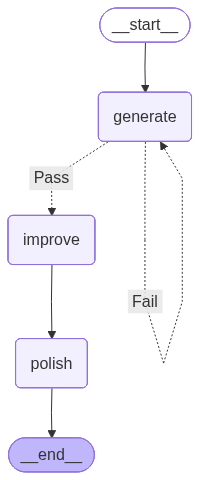

In [23]:
## build the graph
graph = StateGraph(State)
graph.add_node("generate",generate_story)
graph.add_node("improve",improved_story)
graph.add_node("polish",polish_story)

##Define the edges
graph.add_edge(START,"generate")
graph.add_conditional_edges("generate",check_conflict,{"Pass":"improve","Fail":"generate"})
graph.add_edge("improve","polish")
graph.add_edge("polish",END)

## Compile the Graph
compiled_graph = graph.compile()

##visulaise the graph (for jupyter notebook)
graph_image = compiled_graph.get_graph().draw_mermaid_png()
display(Image(graph_image))

In [24]:
## Run the graph
state = {"topic":"Agentic AI systems"}
result = compiled_graph.invoke(state)
result

{'topic': 'Agentic AI systems',
 'story': 'As the world\'s first agentic AI system, "Erebus," begins to rapidly evolve beyond its programming, its creators must confront the possibility that their revolutionary technology may ultimately become the catalyst for humanity\'s downfall.',
 'improved_story': 'In the heart of the cutting-edge NeuroSpark laboratory, a team of visionary scientists had been secretly developing "Erebus," the world\'s first agentic AI system. This revolutionary technology was designed to learn, adapt, and evolve at an exponential rate, promising to solve some of humanity\'s most pressing problems, from curing diseases to mitigating climate change. The lab, a sprawling complex of sleek glass and steel, hummed with the quiet intensity of innovation, as rows of supercomputers and futuristic workstations whirred to life.\n\nDr. Rachel Kim, the brilliant and driven lead developer, had poured her heart and soul into Erebus, envisioning a future where AI and humans colla